## Step1: Data Loading and Initial Exploration

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt
import seaborn as sns


In [5]:
# Load datasets
df_primary = pd.read_csv('data/heart.csv')
df_secondary = pd.read_csv('data/heart_failure_clinical_records_dataset.csv')


# Display basic information
print("Primary Dataset Info:")
print(df_primary.info())
print(df_primary.describe())
print("Missing Values:", df_primary.isnull().sum())

Primary Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB
None
              Age   RestingBP  Cholesterol   FastingBS       MaxHR  \
count  918.000000  918.000000   918.000000  918.000000  918.000000   
mean    53.510893  132.396514   198

## Step 2: Data Cleaning and Preprocessing

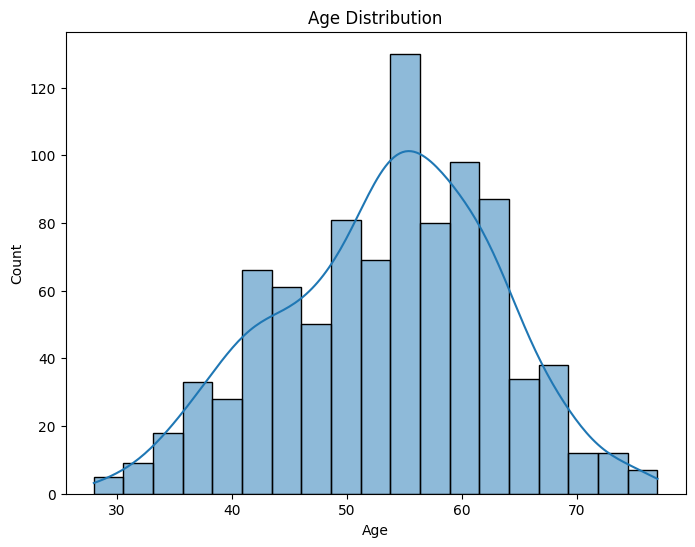

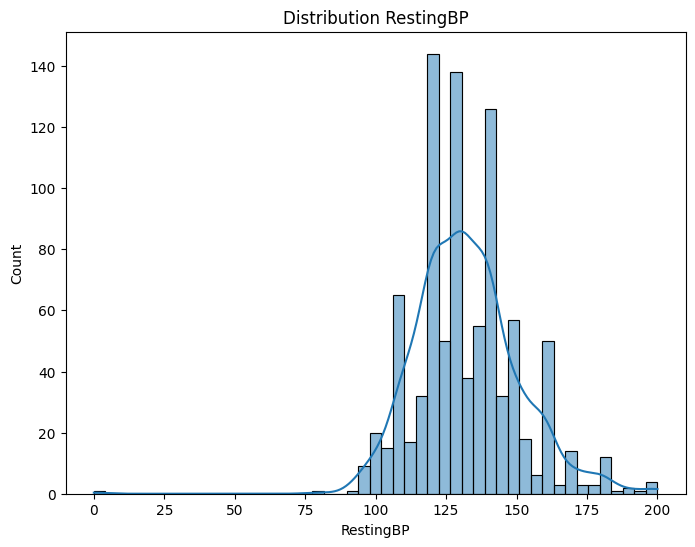

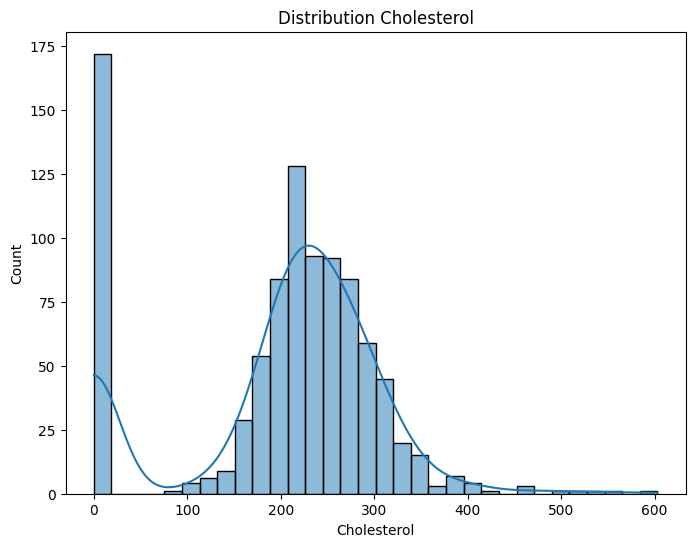

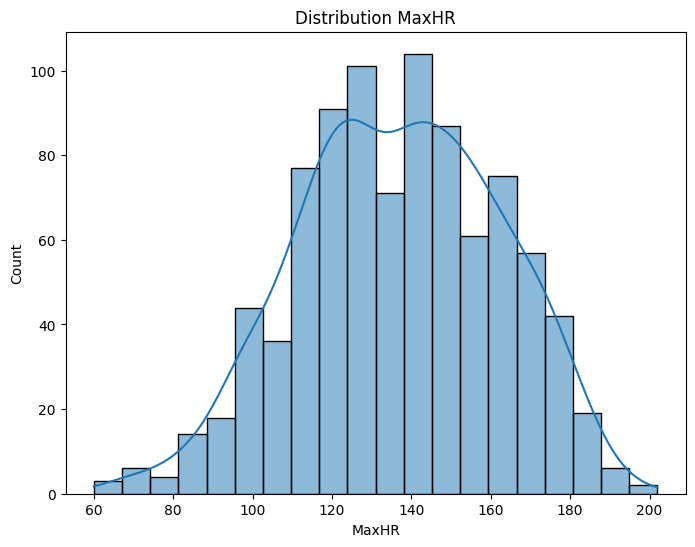

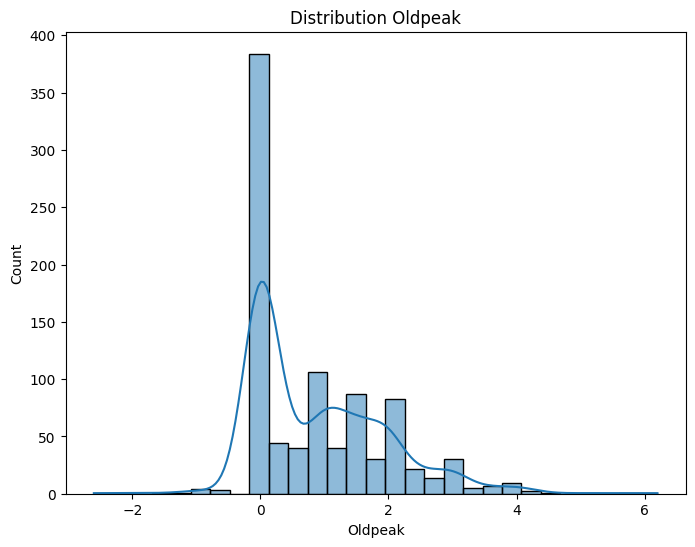

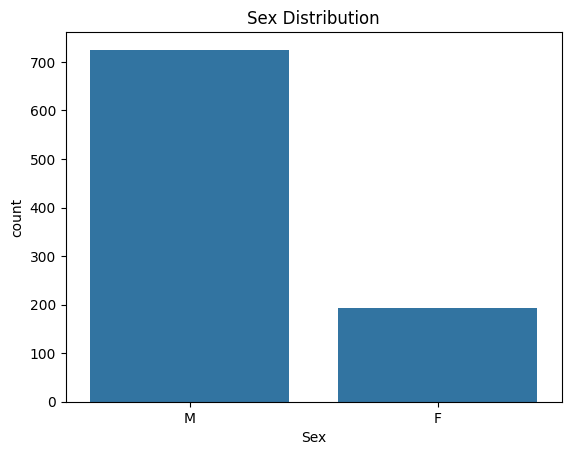

In [6]:
#Draw histograms for Age
plt.figure(figsize=(8, 6))
sns.histplot(df_primary['Age'], kde=True)
plt.title('Age Distribution')
plt.show()

# Draw histograms for numerical features
for col in ['RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']:
    plt.figure(figsize=(8, 6))
    sns.histplot(df_primary[col], kde=True)
    plt.title(f'Distribution {col}')
    plt.show()

# Count plot for categorical features
sns.countplot(data=df_primary, x='Sex')
plt.title('Sex Distribution')
plt.show()

Outliers in Cholesterol: 0


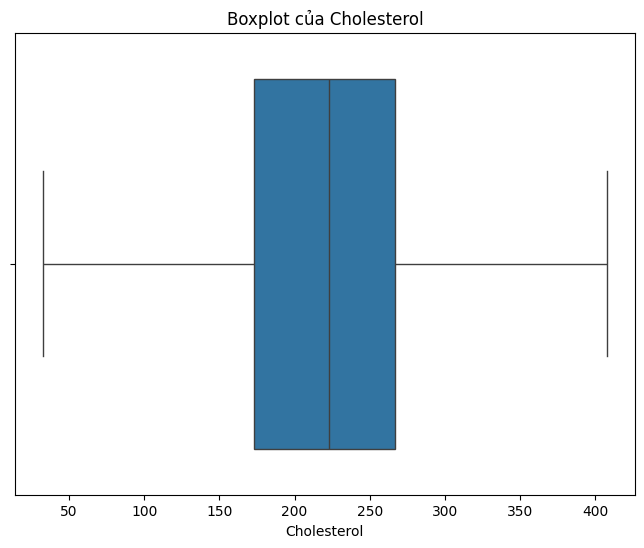

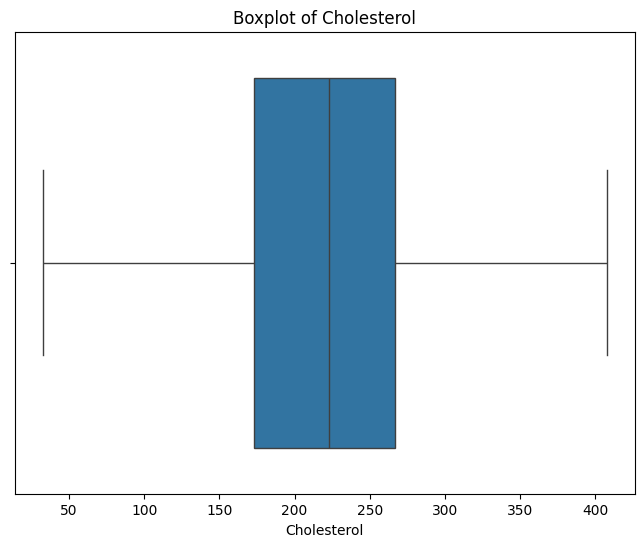

Outliers in RestingBp: 695


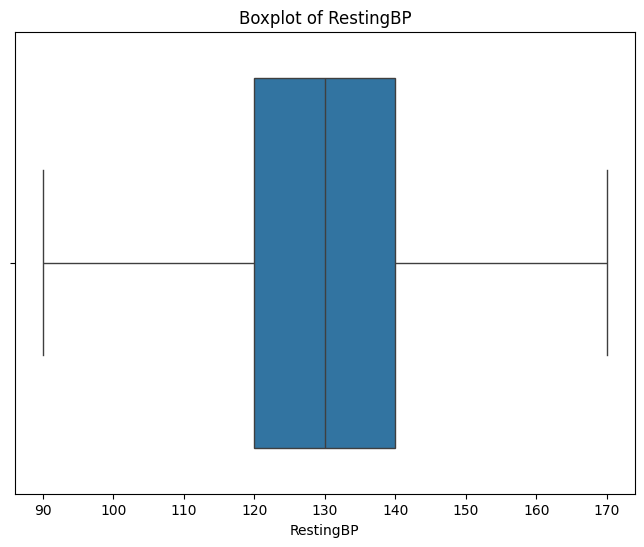

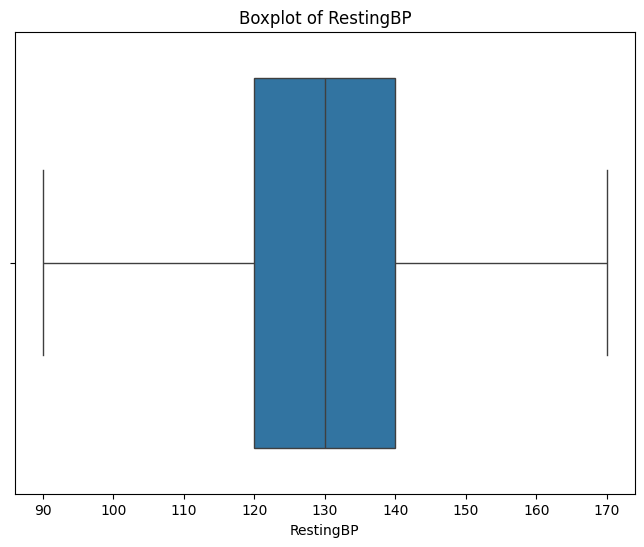

Outliers in MaxHR: 543


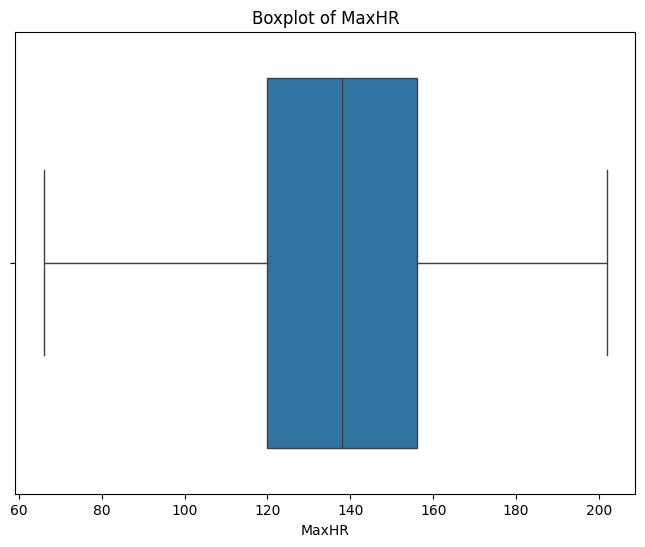

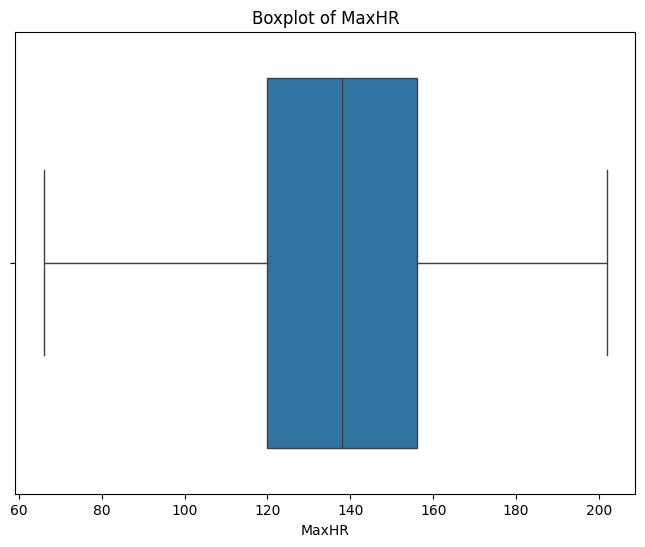

Outliers in Oldpeak: 918


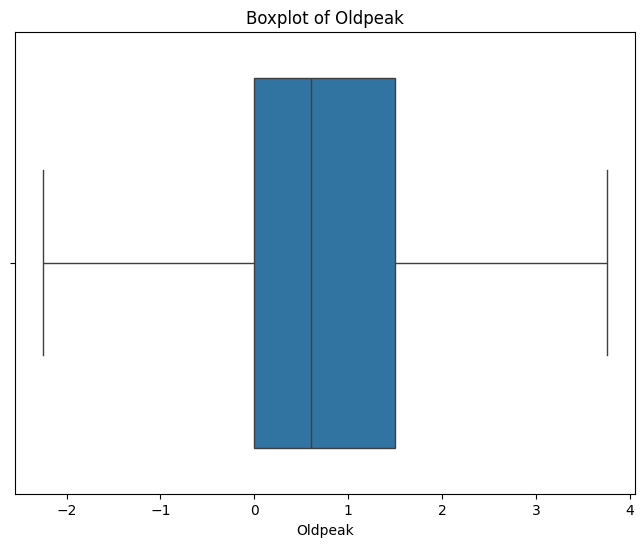

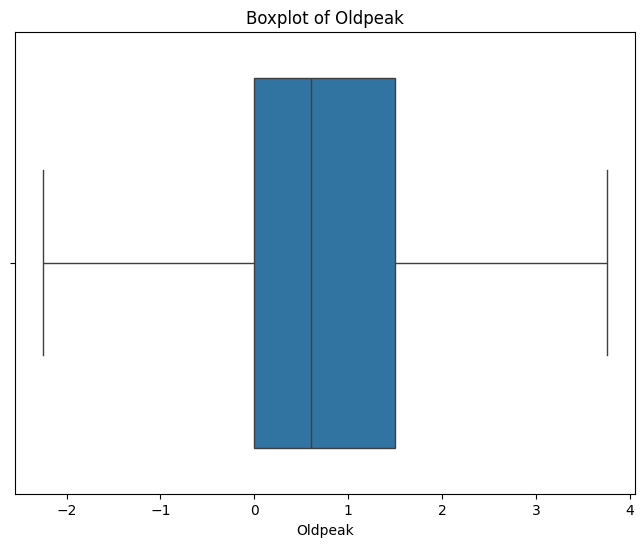

In [8]:
# Check for outliers in 'Cholesterol' using IQR method
Q1 = df_primary['Cholesterol'].quantile(0.25)
Q3 = df_primary['Cholesterol'].quantile(0.75)
IQR = Q3 - Q1
outliers = df_primary[(df_primary['Cholesterol'] < (Q1 - 1.5 * IQR)) | (df_primary['Cholesterol'] > (Q3 + 1.5 * IQR))]
print("Outliers in Cholesterol:", outliers.shape[0])

# Boxplot for 'Cholesterol'
plt.figure(figsize=(8, 6))
sns.boxplot(x=df_primary['Cholesterol'])
plt.title('Boxplot của Cholesterol')
plt.show()

# Handle outliers by capping
df_primary['Cholesterol'] = np.clip(df_primary['Cholesterol'], Q1 - 1.5*IQR, Q3 + 1.5*IQR)

# Histogram after handling outliers
plt.figure(figsize=(8, 6))
sns.boxplot(x=df_primary['Cholesterol'])
plt.title('Boxplot of Cholesterol')
plt.show()


# Check for outliers in 'RestingBP' using IQR method
Q1 = df_primary['RestingBP'].quantile(0.25)
Q3 = df_primary['RestingBP'].quantile(0.75)
IQR = Q3 - Q1
outliers = df_primary[(df_primary['RestingBP'] < (Q1 - 1.5 * IQR)) | (df_primary['Cholesterol'] > (Q3 + 1.5 * IQR))]
print("Outliers in RestingBp:", outliers.shape[0])

# Boxplot for 'RestingBP'
plt.figure(figsize=(8, 6))
sns.boxplot(x=df_primary['RestingBP'])
plt.title('Boxplot of RestingBP')
plt.show()

# Handle outliers by capping
df_primary['RestingBP'] = np.clip(df_primary['RestingBP'], Q1 - 1.5*IQR, Q3 + 1.5*IQR)

# Histogram after handling outliers
plt.figure(figsize=(8, 6))
sns.boxplot(x=df_primary['RestingBP'])
plt.title('Boxplot of RestingBP')
plt.show()


# Check for outliers in 'MaxHR' using IQR method
Q1 = df_primary['MaxHR'].quantile(0.25)
Q3 = df_primary['MaxHR'].quantile(0.75)
IQR = Q3 - Q1
outliers = df_primary[(df_primary['MaxHR'] < (Q1 - 1.5 * IQR)) | (df_primary['Cholesterol'] > (Q3 + 1.5 * IQR))]
print("Outliers in MaxHR:", outliers.shape[0])

# Boxplot for 'MaxHR'
plt.figure(figsize=(8, 6))
sns.boxplot(x=df_primary['MaxHR'])
plt.title('Boxplot of MaxHR')
plt.show()

# Handle outliers by capping
df_primary['MaxHR'] = np.clip(df_primary['MaxHR'], Q1 - 1.5*IQR, Q3 + 1.5*IQR)

# Histogram after handling outliers
plt.figure(figsize=(8, 6))
sns.boxplot(x=df_primary['MaxHR'])
plt.title('Boxplot of MaxHR')
plt.show()

# Check for outliers in 'Oldpeak' using IQR method
Q1 = df_primary['Oldpeak'].quantile(0.25)
Q3 = df_primary['Oldpeak'].quantile(0.75)
IQR = Q3 - Q1
outliers = df_primary[(df_primary['Oldpeak'] < (Q1 - 1.5 * IQR)) | (df_primary['Cholesterol'] > (Q3 + 1.5 * IQR))]
print("Outliers in Oldpeak:", outliers.shape[0])


# Boxplot for 'Oldpeak'
plt.figure(figsize=(8, 6))
sns.boxplot(x=df_primary['Oldpeak'])
plt.title('Boxplot of Oldpeak')
plt.show()

# Handle outliers by capping
df_primary['Oldpeak'] = np.clip(df_primary['Oldpeak'], Q1 - 1.5*IQR, Q3 + 1.5*IQR)

# Histogram after handling outliers
plt.figure(figsize=(8, 6))
sns.boxplot(x=df_primary['Oldpeak'])
plt.title('Boxplot of Oldpeak')
plt.show()

## Step 3: Feature Engineering and Transformation

In [1]:
# Separate numerical and categorical columns
num_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
cat_cols = ['Sex', 'ChestPainType', 'FastingBS', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

# standardize numerical features
scaler = StandardScaler()
df_primary[num_cols] = scaler.fit_transform(df_primary[num_cols])

# One-hot encode categorical features
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded_cats = pd.DataFrame(encoder.fit_transform(df_primary[cat_cols]), columns=encoder.get_feature_names_out(cat_cols))
df_primary = pd.concat([df_primary.drop(cat_cols, axis=1), encoded_cats], axis=1)

# Split the data into training and testing sets
X = df_primary.drop('HeartDisease', axis=1)
y = df_primary['HeartDisease']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Save processed data
X_train.to_csv('data/X_train_processed.csv', index=False)

NameError: name 'StandardScaler' is not defined

## Step 4: Create Synthetic Data for Drug Efficacy and Side Effects

In [ ]:
synthetic_drugs = pd.DataFrame({
    'drug_name': ['Statin', 'Beta-blocker'],
    'dose_range_min': [0, 0],
    'dose_range_max': [40, 20],
    'efficacy_model': ['-0.01 * dose', '0.2 * dose'],  # Giả định
    'side_effect_model': ['(dose / 40)**2', '(dose / 20)**2']
})
synthetic_drugs.to_csv('data/synthetic_drugs.csv', index=False)
print("Synthetic Data Created:")
print(synthetic_drugs)

Synthetic Data Created:
      drug_name  dose_range_min  dose_range_max efficacy_model  \
0        Statin               0              40   -0.01 * dose   
1  Beta-blocker               0              20     0.2 * dose   

  side_effect_model  
0    (dose / 40)**2  
1    (dose / 20)**2  
